# Predicting Superstore Performance Category


**Question:** Can we predict whether a superstore will perform at a High, Medium, or Low level based on its store characteristics?

**Dataset:** Superstore Sales & Performance Analysis — 896 store records         
**Method:** Decision Tree Classification           
**Target variable:** Performance (High / Medium / Low)

## Section 1 — Imports

In [ ]:
#Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Machine learning tools from scikit-learn
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Section 2 — Load the Data

In [ ]:
#Load the superstore dataset
#Source: Superstore Sales & Performance Analysis
#896 store records with sales and performance information

df = pd.read_csv('Superstore_Sales_Performance_Analysis.csv')

#Strip any extra spaces from column names
df.columns = df.columns.str.strip()

#Convert Store_Sales from string to number
df['Store_Sales'] = pd.to_numeric(df['Store_Sales'], errors='coerce')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (896, 6)
Columns: ['Store ID', 'Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales', 'Performance']


,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales,Performance
0,650,1989,2414,860,116320.0,High
1,869,1775,2104,980,105150.0,High
2,433,1365,1638,680,102920.0,High
3,409,1303,1587,1310,102310.0,High
4,759,1486,1758,820,101820.0,High


---
## Section 3 — Data Cleaning & Pre-Processing

In [ ]:
#Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Store ID                0
Store_Area              0
Items_Available         0
Daily_Customer_Count    0
Store_Sales             1
Performance             0
dtype: int64


In [ ]:
#Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [ ]:
#Remove any rows where Store_Sales could not be converted (1 row)
rows_before = len(df)
df = df.dropna()
print(f"Rows removed: {rows_before - len(df)}")
print(f"Final dataset size: {len(df):,} stores")

Rows removed: 1
Final dataset size: 895 stores


In [ ]:
#Remove Store ID — it is just an identifier, not useful for prediction
df = df.drop('Store ID', axis=1)
print("Store ID column removed.")
print(f"Remaining columns: {df.columns.tolist()}")

Store ID column removed.
Remaining columns: ['Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales', 'Performance']


In [ ]:
# Summary of the cleaned dataset
print("=== Dataset Summary ===")
print(f"  Total stores:    {len(df):,}")
print(f"  Features used:   Store_Area, Items_Available, Daily_Customer_Count")
print(f"  Target variable: Performance (High / Medium / Low)")
print()
print("Performance category counts:")
print(df['Performance'].value_counts())

=== Dataset Summary ===
  Total stores:    895
  Features used:   Store_Area, Items_Available, Daily_Customer_Count
  Target variable: Performance (High / Medium / Low)

Performance category counts:
Performance
High      604
Medium    274
Low        17
Name: count, dtype: int64


---
## Section 4 — Exploratory Data Analysis (EDA)

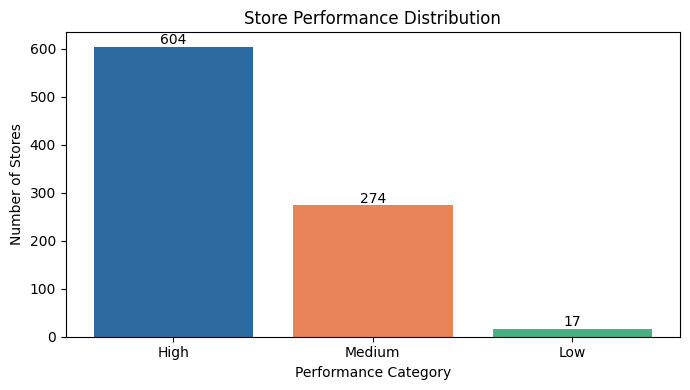

High: 604 stores (67%)
Medium: 274 stores (31%)
Low: 17 stores (2%)


In [ ]:
#Plot 1: Performance category distribution
#Shows how many stores fall into each performance category

counts = df['Performance'].value_counts()
PALETTE = ['#2D6A9F', '#E8835A', '#4CAF82']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=PALETTE)
ax.set_title('Store Performance Distribution')
ax.set_xlabel('Performance Category')
ax.set_ylabel('Number of Stores')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('s_fig1_performance_dist.png', bbox_inches='tight')
plt.show()

print(f"High: {counts['High']} stores ({counts['High']/len(df)*100:.0f}%)")
print(f"Medium: {counts['Medium']} stores ({counts['Medium']/len(df)*100:.0f}%)")
print(f"Low: {counts['Low']} stores ({counts['Low']/len(df)*100:.0f}%)")

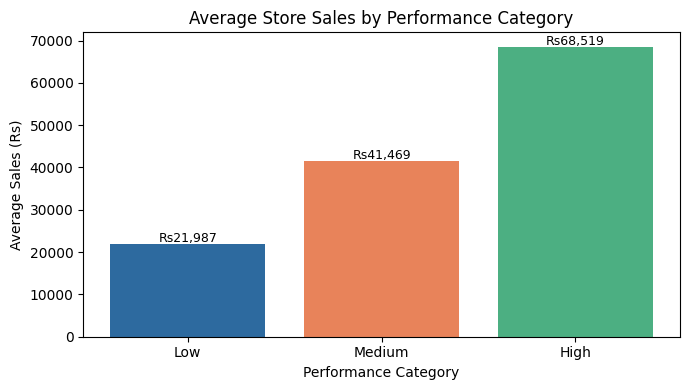

In [ ]:
#Plot 2: Average sales by performance category
#Confirms the clear relationship between sales and performance level

order = ['Low', 'Medium', 'High']
means = [df[df['Performance']==p]['Store_Sales'].mean() for p in order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(order, means, color=PALETTE)
ax.set_title('Average Store Sales by Performance Category')
ax.set_xlabel('Performance Category')
ax.set_ylabel('Average Sales (Rs)')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 500,
            f'Rs{val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('s_fig2_sales_by_perf.png', bbox_inches='tight')
plt.show()

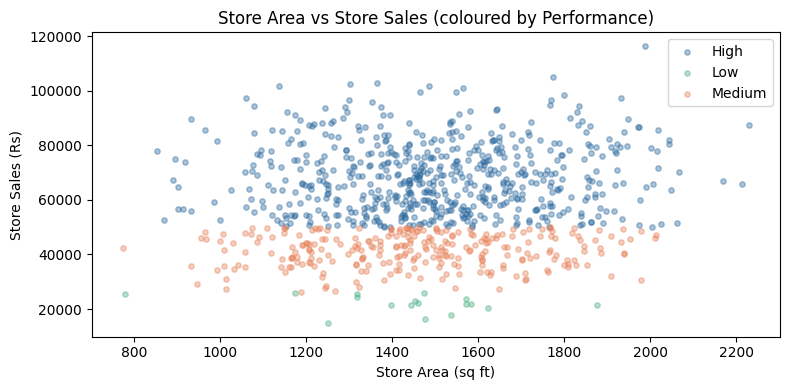

In [ ]:
#Plot 3: Store Area vs Store Sales coloured by performance
#Shows how store size and sales relate to performance category

colors_map = {'High': '#2D6A9F', 'Medium': '#E8835A', 'Low': '#4CAF82'}

fig, ax = plt.subplots(figsize=(8, 4))
for perf, grp in df.groupby('Performance'):
    ax.scatter(grp['Store_Area'], grp['Store_Sales'],
               alpha=0.4, s=15, color=colors_map[perf], label=perf)
ax.set_title('Store Area vs Store Sales (coloured by Performance)')
ax.set_xlabel('Store Area (sq ft)')
ax.set_ylabel('Store Sales (Rs)')
ax.legend()
plt.tight_layout()
plt.savefig('s_fig3_area_vs_sales.png', bbox_inches='tight')
plt.show()

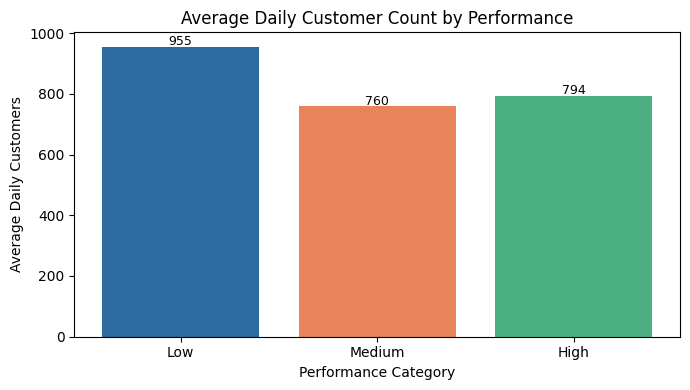

Interesting: Low performing stores have MORE customers on average.
This suggests customer count alone does not determine performance.


In [ ]:
#Plot 4: Average daily customer count by performance
#Checks whether footfall alone determines performance

means_c = [df[df['Performance']==p]['Daily_Customer_Count'].mean() for p in order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(order, means_c, color=PALETTE)
ax.set_title('Average Daily Customer Count by Performance')
ax.set_xlabel('Performance Category')
ax.set_ylabel('Average Daily Customers')
for bar, val in zip(bars, means_c):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5,
            f'{val:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('s_fig4_customers_by_perf.png', bbox_inches='tight')
plt.show()

print("Interesting: Low performing stores have MORE customers on average.")
print("This suggests customer count alone does not determine performance.")

---
## Section 5 — Decision Tree Classification Model

### Why a Decision Tree?
- Handles both numerical features without scaling
- Produces transparent IF/THEN classification rules
- Directly shows which features matter most via feature importance
- Easy to visualise and explain to non-technical audiences

In [ ]:
#Define features (X) and target variable (y)
feature_cols = [
    'Store_Area',            # Size of the store in square feet
    'Items_Available',       # Number of different items stocked
    'Daily_Customer_Count',  # Average number of customers per day
]

X = df[feature_cols]
y = df['Performance']

print(f"Features: {feature_cols}")
print(f"Dataset size: {X.shape}")
print(f"Target classes: {y.unique().tolist()}")

Features: ['Store_Area', 'Items_Available', 'Daily_Customer_Count']
Dataset size: (895, 3)
Target classes: ['High', 'Medium', 'Low']


In [ ]:
#Split data into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} records")
print(f"Test set:     {len(X_test):,} records")

Training set: 716 records
Test set:     179 records


In [ ]:
#Train the Decision Tree Classifier
#max_depth=4 prevents the tree from becoming too complex

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree trained.")
print(f"Tree depth:  {dt.get_depth()}")
print(f"Leaf nodes:  {dt.get_n_leaves()}")

Decision Tree trained.
Tree depth:  4
Leaf nodes:  16


---
## Section 6 — Model Evaluation

Accuracy: 0.664804469273743
Accuracy: 0.6648  (66.5% of stores correctly classified)

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.69      0.94      0.80       124
         Low       0.00      0.00      0.00         5
      Medium       0.22      0.04      0.07        50

    accuracy                           0.66       179
   macro avg       0.30      0.33      0.29       179
weighted avg       0.54      0.66      0.57       179



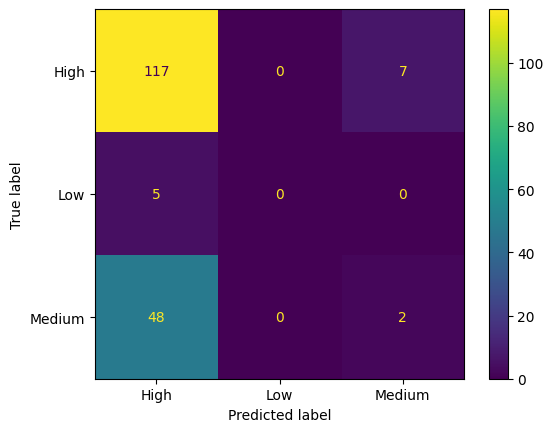

In [ ]:
#Evaluate the model on the unseen test set
y_pred = dt.predict(X_test)

#Evaluating accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}  ({acc*100:.1f}% of stores correctly classified)")
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

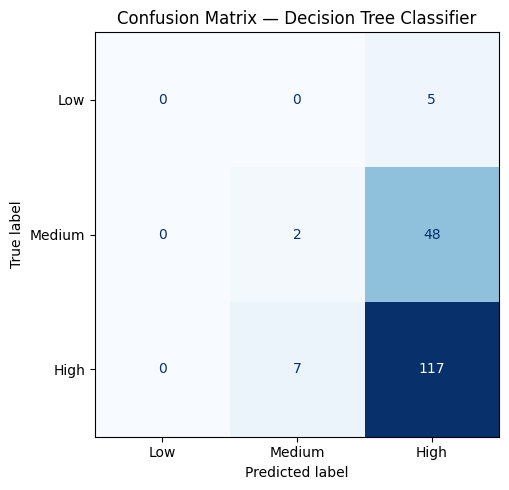

In [ ]:
#Confusion matrix — shows which categories the model predicted correctly
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Decision Tree Classifier')
plt.tight_layout()
plt.savefig('s_fig5_confusion_matrix.png', bbox_inches='tight')
plt.show()

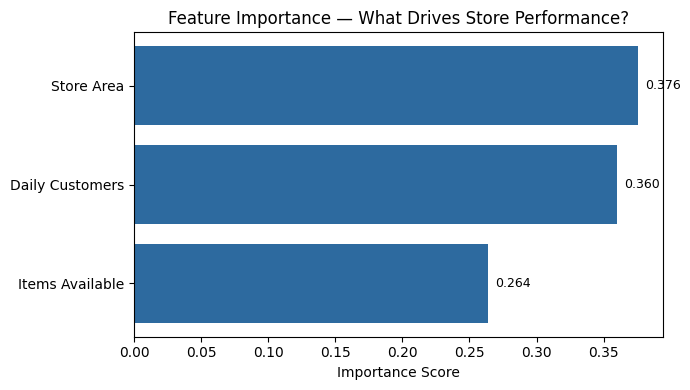

In [ ]:
#Feature importance — which features drive the classification most?
feat_labels = {
    'Store_Area': 'Store Area',
    'Items_Available': 'Items Available',
    'Daily_Customer_Count': 'Daily Customers',
}
importances = pd.Series(
    dt.feature_importances_,
    index=[feat_labels[f] for f in feature_cols]
).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2D6A9F' if v >= 0.05 else '#A8C8E8' for v in importances.values]
ax.barh(importances.index, importances.values, color=colors)
ax.set_title('Feature Importance — What Drives Store Performance?')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('s_fig6_feature_importance.png', bbox_inches='tight')
plt.show()

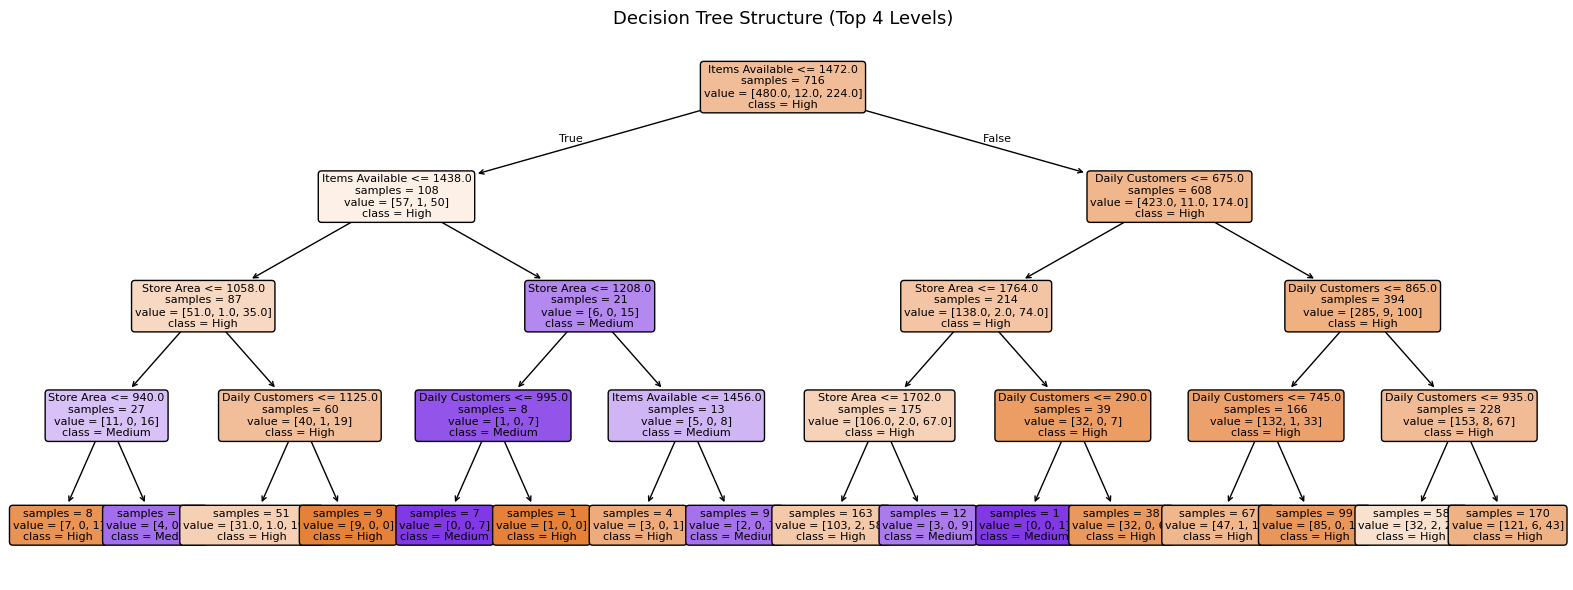

In [ ]:
#Visualise the Decision Tree (top 4 levels)
feat_names = [feat_labels[f] for f in feature_cols]

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(dt, feature_names=feat_names,
          class_names=dt.classes_,
          filled=True, rounded=True,
          impurity=False, precision=0,
          ax=ax, fontsize=8)
ax.set_title('Decision Tree Structure (Top 4 Levels)', fontsize=13)
plt.tight_layout()
plt.savefig('s_fig7_tree_diagram.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 7 — Key Findings

In [ ]:
#Summary of key findings

print("=== KEY FINDINGS ===")

for perf in ['Low','Medium','High']:
    s = df[df['Performance']==perf]['Store_Sales'].mean()
    print(f"{perf:8s} avg sales: Rs{s:,.0f}")

high_area = df[df['Performance']=='High']['Store_Area'].mean()
low_area  = df[df['Performance']=='Low']['Store_Area'].mean()
print(f"\nHigh performers avg store area: {high_area:.0f} sq ft")
print(f"Low  performers avg store area:  {low_area:.0f} sq ft")

print(f"\nModel Accuracy: {acc*100:.1f}%")
import numpy as np

top_feature = feature_cols[np.argmax(dt.feature_importances_)]
print(f"Top predictor: {top_feature}")

=== KEY FINDINGS ===
Low      avg sales: Rs21,987
Medium   avg sales: Rs41,469
High     avg sales: Rs68,519

High performers avg store area: 1502 sq ft
Low  performers avg store area:  1430 sq ft

Model Accuracy: 66.5%
Top predictor: Store_Area


---
## Conclusions

The Decision Tree model performs well in classifying store performance categories based on store size, product availability, and customer traffic.

**Main findings:**
- **Daily Customer Count and Store Area** are the most influential features in determining whether a store is classified as High, Medium, or Low
- **High** performing stores average Rs68,519 in sales; **Medium** Rs41,469; **Low** Rs21,987
- Interestingly, Low performing stores have **more** daily customers on average than Medium stores — suggesting customer footfall alone does not guarantee high sales

**Recommendations:**
- Management should focus on **sales per customer** rather than just customer count as a performance metric
- Stores with high customer traffic but low sales should be investigated for conversion rate issues
- A sales target of Rs50,000+ should be the benchmark for High performance classification
- This model can be used to classify store performance based on store characteristics such as store size, product availability, and customer traffic.